In [61]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np


In [ ]:
# Function to try to match:

def f(x,y):
    return 1/(1+(x+y)**2)

In [77]:
def fv(Xs):
    return f(Xs[:, 0], Xs[:, 1])

In [63]:
# Range to try to match in:
minima = (-2, -2)
maxima = (2, 2)

In [69]:
class Sampler:
    def __init__(self, engine, minima, maxima):
        self.engine = engine
        self.range = self.engine.array(maxima)[None, :] - self.engine.array(minima)[None, :]
        self.low = self.engine.array(minima)[None, :]

    def samples(self, n):
        return self.engine.random.uniform(size=(n, 2)) * self.range + self.low

In [70]:
# Sampler function to generate input data:
class JaxSampler(Sampler):
    def __init__(self, minima, maxima):
        super().__init__(jnp, minima, maxima)
        self.key = jax.random.key(0)

    def samples(self, count):
        key, subkey = jax.random.split(self.key)
        res = jax.random.uniform(subkey, (count, 2)) * self.range + self.low
        return res

In [71]:
sampler = Sampler(np, minima, maxima)

In [72]:
print(sampler.samples(5))

[[-0.375617   -1.11854618]
 [ 1.01562449 -0.19595789]
 [-0.0345157   0.13577266]
 [ 1.06991223  1.68452779]
 [-0.17343568  0.97978346]]


In [73]:
print(JaxSampler(minima, maxima).samples(5))

[[-1.9708247  -1.9164352 ]
 [ 0.325706   -0.55264807]
 [-1.1078491  -1.5228467 ]
 [-1.4982443   0.46731997]
 [-1.6199708   1.9336901 ]]


(200, 200) (200, 200) (200, 200)


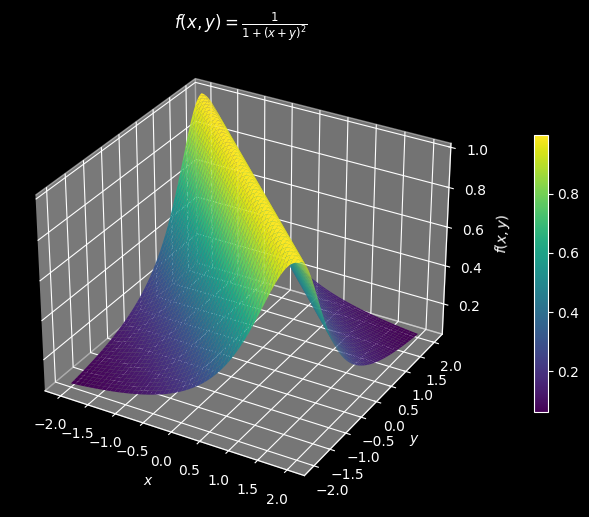

In [ ]:
# 3-D plot of the function
x = jnp.linspace(minima[0], maxima[0], 200)
y = jnp.linspace(minima[1], maxima[1], 200)
X, Y = jnp.meshgrid(x, y)
Z = f(X, Y)
plt.style.use("dark_background")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

ax.set_title("$f(x, y) = \\frac{1}{1+(x+y)^2}$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$f(x, y)$")
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)

plt.show()


(40000, 2)


In [ ]:
Z = f(X, Y)

plt.style.use("dark_background")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

ax.set_title("$f(x, y) = \\frac{1}{1+(x+y)^2}$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$f(x, y)$")
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)

plt.show()

In [91]:
X_train = sampler.samples(100)
y_train = fv(X_train)

In [93]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(X_train, y_train)
gaussian_process.kernel_

0.298**2 * RBF(length_scale=0.592)

In [101]:
Xs = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
means, ranges = gaussian_process.predict(Xs, return_std=True)
means = means.reshape(X.shape)
ranges = ranges.reshape(X.shape)

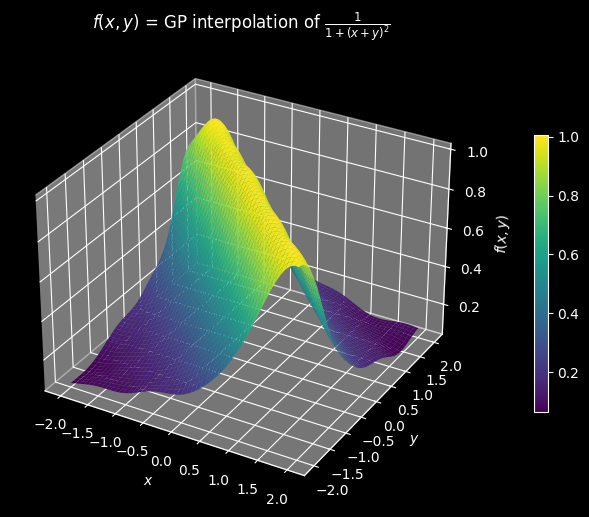

In [103]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(X, Y, means, cmap="viridis", edgecolor="none")

ax.set_title("$f(x, y)$ = GP interpolation of $\\frac{1}{1+(x+y)^2}$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$f(x, y)$")
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)

plt.show()

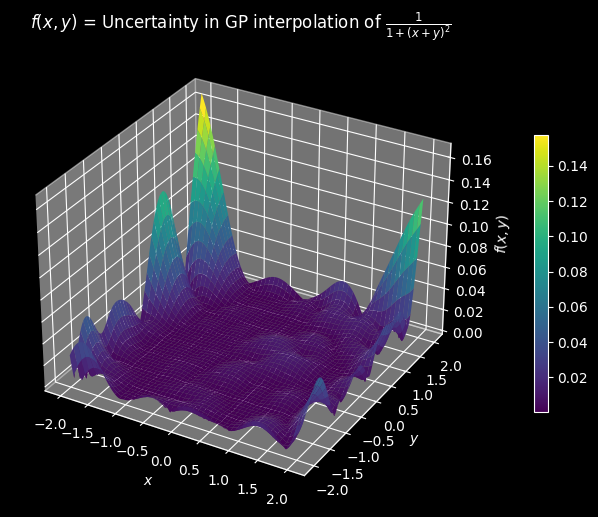

In [104]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(X, Y, ranges, cmap="viridis", edgecolor="none")

ax.set_title("$f(x, y)$ = Uncertainty in GP interpolation of $\\frac{1}{1+(x+y)^2}$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$f(x, y)$")
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)

plt.show()